# Week Six - Assignment Data Sets

Here is a dataset that shows a simple 2-node network:  the attendance of 18 Southern Women at 14 social events:

Brief Description. Small “musty” datasets like that from this 1941 study have proven very valuable in testing and comparing new network algorithms.


Python code to create dataset: https://networkx.github.io/documentation/stable/auto_examples/algorithms/plot_davis_club.html
What can you infer about the relationships between 

(1) the women,

(2) the social events?

In [2]:
import networkx as nx
import matplotlib.pyplot as plt
from networkx.algorithms import bipartite

## Let's load the dataset in networkX and separate the women and their clubs

In [11]:
G = nx.davis_southern_women_graph()

women = G.graph['top']
clubs = G.graph['bottom']

print('Biadjacency matrix')
print(bipartite.biadjacency_matrix(G, women, clubs))

Biadjacency matrix
<Compressed Sparse Row sparse array of dtype 'int64'
	with 89 stored elements and shape (18, 14)>
  Coords	Values
  (0, 0)	1
  (0, 1)	1
  (0, 2)	1
  (0, 3)	1
  (0, 4)	1
  (0, 5)	1
  (0, 7)	1
  (0, 8)	1
  (1, 0)	1
  (1, 1)	1
  (1, 2)	1
  (1, 4)	1
  (1, 5)	1
  (1, 6)	1
  (1, 7)	1
  (2, 1)	1
  (2, 2)	1
  (2, 3)	1
  (2, 4)	1
  (2, 5)	1
  (2, 6)	1
  (2, 7)	1
  (2, 8)	1
  (3, 0)	1
  (3, 2)	1
  :	:
  (12, 7)	1
  (12, 8)	1
  (12, 9)	1
  (12, 11)	1
  (12, 12)	1
  (12, 13)	1
  (13, 5)	1
  (13, 6)	1
  (13, 8)	1
  (13, 9)	1
  (13, 10)	1
  (13, 11)	1
  (13, 12)	1
  (13, 13)	1
  (14, 6)	1
  (14, 7)	1
  (14, 9)	1
  (14, 10)	1
  (14, 11)	1
  (15, 7)	1
  (15, 8)	1
  (16, 8)	1
  (16, 10)	1
  (17, 8)	1
  (17, 10)	1


## Projecting the bipartite network into a one-mode network:

1) This loop returns a list of women who have attended at least one event together.

2) The "#Friend" number represents the number of other women that the specific person shares at least one event with.

In [47]:
W = bipartite.projected_graph(G, women)

social_list = []
for w in women:
    social_list.append((W.degree(w), w))

sorted_list = sorted(social_list, reverse=True)
print('#Friend | name')
for degree, name in sorted_list:
    print(f'{degree}      | {name}')


#Friend | name
17      | Verne Sanderson
17      | Theresa Anderson
17      | Sylvia Avondale
17      | Ruth DeSand
17      | Nora Fayette
17      | Helen Lloyd
17      | Evelyn Jefferson
16      | Pearl Oglethorpe
16      | Myra Liddel
16      | Katherina Rogers
16      | Dorothy Murchison
15      | Laura Mandeville
15      | Frances Anderson
15      | Eleanor Nye
15      | Brenda Rogers
12      | Olivia Carleton
12      | Flora Price
11      | Charlotte McDowd


## Let's generate a weighted connection to compute a weighted calculation on the relationships
Weighted projection:

1) The main idea of this weighted computation is to calculate the magnatidue of event attendance of each of these women and the total occurence of them meeting other women

2) The "#Friend meetings" represents the cumculative sum of other women that are met in the events. The higher the number, the more active this person is to attend events that are popular, which allows more women to attend.

In [57]:
weighted = bipartite.weighted_projected_graph(G, women)

print('#Friend meetings | Member')
weighted_list = []
for w in women:
    weighted_list.append((weighted.degree(w, weight='weight'), w))

sorted_weight_list = sorted(weighted_list, reverse=True)

for weight_degree, name in sorted_weight_list:
    print(f'{weight_degree}      | {name}')

#Friend meetings | Member
57      | Theresa Anderson
50      | Evelyn Jefferson
46      | Sylvia Avondale
46      | Brenda Rogers
45      | Laura Mandeville
43      | Nora Fayette
40      | Ruth DeSand
38      | Verne Sanderson
37      | Katherina Rogers
36      | Eleanor Nye
34      | Helen Lloyd
33      | Myra Liddel
32      | Frances Anderson
31      | Pearl Oglethorpe
24      | Dorothy Murchison
24      | Charlotte McDowd
14      | Olivia Carleton
14      | Flora Price


To visualize the weighted plot:

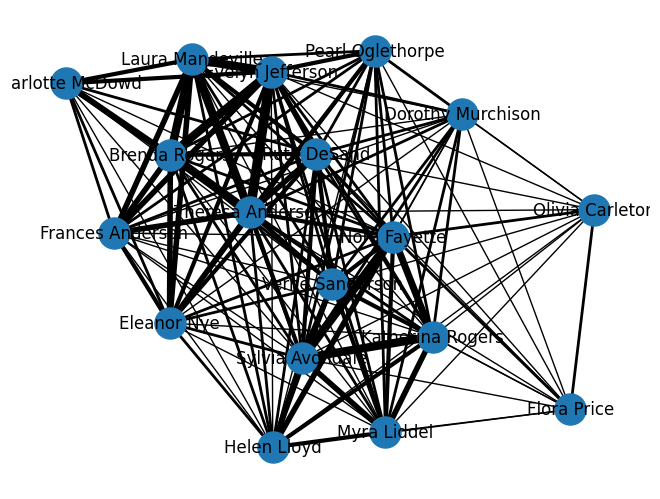

In [28]:
weighted = bipartite.weighted_projected_graph(G, women)
#Extract the weights of each connection:
edge_weights = [weighted[u][v]['weight'] for u, v in weighted.edges()]

pos_w = nx.spring_layout(weighted, seed=42)

nx.draw(weighted, pos_w, width=edge_weights, with_labels=True, node_size=500 )
plt.show()

## Are there any shared names that appear more frequently?
Let's observe if the top 7 women who attended events together also happened to be the same women who have the most cumculative attendence to events:

 #### The number 7 is chosen because we have 7 women who are shared the most #Friend in the unweighted list

In [71]:
unweighted_names = [name for degree, name in sorted_list[:7]]
weighted_names = [name for degree, name in sorted_weight_list[:7]]

top_7 = [name for name in unweighted_names if name in weighted_names]
print(top_7)

['Theresa Anderson', 'Sylvia Avondale', 'Ruth DeSand', 'Nora Fayette', 'Evelyn Jefferson']


5 out of 7 women appeared on top list also appear in both lists.

Conclusion:


Based on the biopartite graphs, we can conclude that women who are more active in attending events are more likely to meet with other women who are equally active in attending events. This is demonstrated by the "top_7" list above, where 5 out of 7 of the top women who attend and connect with other women. These five women have the most degree of connection and attendence to events and at the same time they also have the most number of connections with each other in addition to other women who attend the event. In other words, the more like a women is to be active in event attendence, they more likely they will meet with others who will do the same.

In terms of the social events, they serve as the metrics to calculate the likelihood of two people meeting each other. The use of weighted graph helps to reveal whether the occurence of two women meeting each other is more frequent than with other people. While we cannot be certain if the two have real interactions or purely attending the event without any interaction, we can infer that if the occurance of attending the same event is higher the chances of these women are more likely to have interactions.